In [1]:
from olist.seller import Seller
from olist.data import Olist
data = Olist().get_data()

In [2]:

ois = data['order_items']
ors = data['order_reviews']
sellers = Seller().get_training_data()
rc = {
    1: 100,
    2: 50,
    3: 40,
    4: 0,
    5: 0
}

In [3]:
order_seller = ois[['order_id', 'seller_id']].drop_duplicates()
print(f'# of orders {order_seller.nunique().loc['order_id']} \t # of sellers {order_seller.nunique().loc['seller_id']} \t # of pairs {len(order_seller)}')

# of orders 98666 	 # of sellers 3095 	 # of pairs 100010


In [4]:
seller_order_review = order_seller.merge(ors, on='order_id')[['order_id', 'seller_id', 'review_id', 'review_score']]
seller_order_review['review_cost'] = seller_order_review.review_score.map(rc)
review_cost = seller_order_review.groupby('seller_id', as_index=False).sum()[['seller_id', 'review_cost']]
sellers['review_cost'] = sellers.merge(review_cost, on='seller_id').review_cost

In [5]:
print(f'# of sellers {sellers.seller_id.nunique()} \t # of rows {len(sellers)}')

# of sellers 2967 	 # of rows 2967


In [6]:

sellers

,seller_id,seller_city,seller_state,delay_to_carrier,wait_time,date_first_sale,date_last_sale,months_on_olist,n_orders,quantity,quantity_per_order,sales,share_of_one_stars,share_of_five_stars,review_score,review_cost
0,3442f8959a84dea7ee197c632cb2df15,campinas,SP,0.000000,13.018588,2017-05-05 16:25:11,2017-08-30 12:50:19,4.0,3,3,1.000000,218.70,0.333333,0.333333,3.00,140
1,d1b65fc7debc3361ea86b5f14c68d2e2,mogi guacu,SP,0.000000,9.065716,2017-03-29 02:10:34,2018-06-06 20:15:21,14.0,40,41,1.025000,11703.07,0.050000,0.725000,4.55,240
2,ce3ad9de960102d0677a81f5d0bb7b2d,rio de janeiro,RJ,0.000000,4.042292,2018-07-30 12:44:49,2018-07-30 12:44:49,0.0,1,1,1.000000,158.00,0.000000,1.000000,5.00,0
3,c0f3eea2e14555b6faeea3dd58c1b1c3,sao paulo,SP,0.000000,5.667187,2018-08-03 00:44:08,2018-08-03 00:44:08,0.0,1,1,1.000000,79.99,0.000000,1.000000,5.00,0
4,51a04a8a6bdcb23deccc82b0b80742cf,braganca paulista,SP,3.353727,35.314861,2017-11-14 12:15:25,2017-11-14 12:15:25,0.0,1,1,1.000000,167.99,1.000000,0.000000,1.00,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2962,98dddbc4601dd4443ca174359b237166,sarandi,PR,0.000000,8.230822,2018-07-14 03:10:19,2018-07-23 15:34:03,0.0,2,2,1.000000,158.00,0.000000,1.000000,5.00,0
2963,f8201cab383e484733266d1906e2fdfa,palhoca,SC,0.000000,13.045797,2017-06-17 15:30:11,2018-08-11 19:55:17,14.0,10,10,1.000000,889.00,0.100000,0.500000,4.10,140
2964,74871d19219c7d518d0090283e03c137,sao paulo,SP,0.000000,3.606625,2018-04-05 17:09:46,2018-08-21 19:25:15,5.0,6,7,1.166667,550.04,0.000000,1.000000,5.00,0
2965,e603cf3fec55f8697c9059638d6c8eb5,pelotas,RS,0.000000,6.657634,2017-02-09 02:43:17,2017-06-16 17:30:16,4.0,8,11,1.375000,297.00,0.000000,0.500000,4.25,50


In [7]:
cut_income = sellers.sales * .1
sub_income = sellers.months_on_olist * 80
pre_it_profits = cut_income + sub_income - sellers.review_cost
sellers['cut_income'] = cut_income
sellers['sub_income'] = sub_income
sellers['pre_it_profits'] = pre_it_profits

In [8]:
sellers.sort_values('pre_it_profits', ascending=False, inplace=True)
sellers.reset_index(inplace=True, drop=True)

<Axes: >

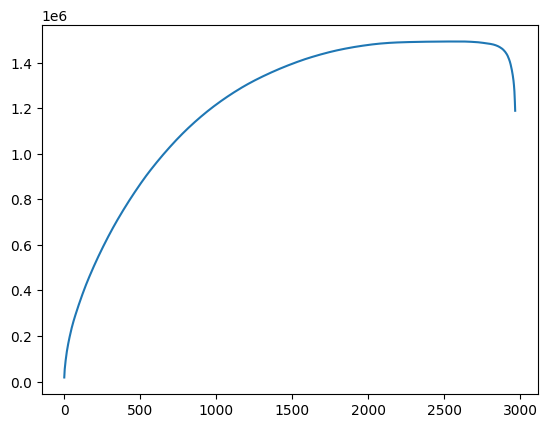

In [9]:
sellers.pre_it_profits.cumsum().plot()

In [10]:
sellers_to_keep = sellers.pre_it_profits > 0

In [11]:
sellers[sellers_to_keep].pre_it_profits.sum()

1493471.956

In [12]:
import numpy as np
alpha = 3157.27
beta = 978.23
def it_cost(ns, ni):
    return alpha * np.sqrt(ns) + beta * np.sqrt(ni)

In [13]:
sellers_exp1 = sellers.copy()

In [14]:
sellers_exp1['num_sellers'] = range(1, len(sellers_exp1) + 1)
sellers_exp1['num_items'] = sellers_exp1.quantity.cumsum()
sellers_exp1['it_cost'] = it_cost(sellers_exp1.num_sellers, sellers_exp1.num_items)
sellers_exp1['post_it_profits'] = sellers_exp1.pre_it_profits.cumsum() - sellers_exp1.it_cost

<Axes: >

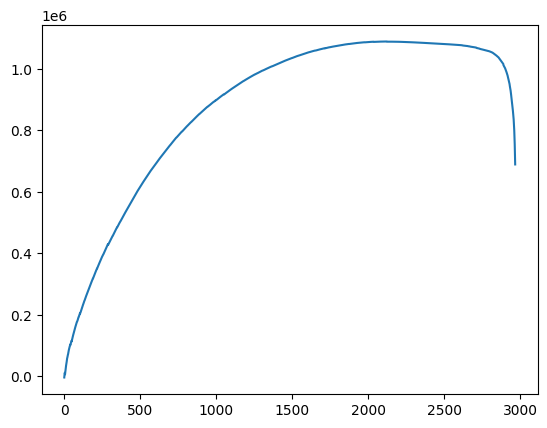

In [15]:
sellers_exp1.post_it_profits.plot()

In [16]:
sellers_exp1.post_it_profits.argmax()

2116

In [17]:
sellers_exp1.post_it_profits.max()

1089860.8482372754

-----------------------
## Research

In [18]:
from optimum_solvers import solve_lagrangian, solve_misocp, refine_local_swap, total_profit, it_cost, summarise

In [19]:
keep_lag = solve_lagrangian(sellers)
keep_lag_refined = refine_local_swap(keep_lag, sellers)

In [20]:
n_sellers = len(sellers[keep_lag])
n_items = sellers[keep_lag].quantity.sum()
it_cost_ = it_cost(n_sellers, n_items)
profits = sellers[keep_lag].pre_it_profits.sum() - it_cost_
print(profits)

1095138.4019854125


In [21]:
import pandas as pd
report = pd.concat([
  summarise(keep_lag,         sellers, label='lagrangian'),
  summarise(keep_lag_refined, sellers, label='lagrangian+swap'),
], ignore_index=True)
report

,method,n_kept,n_total,items_kept,pre_it_profit,it_cost,post_it_profit
0,lagrangian,2109,2967,60339.0,1480424.794,385286.392015,1.095138e+06
1,lagrangian+swap,2109,2967,60339.0,1480424.794,385286.392015,1.095138e+06


In [22]:
from strong_intersection import closed_form_strong_sets, propagate_strong_sets, summarise_sets
K1, D1 = closed_form_strong_sets(sellers)
K2, D2, hist = propagate_strong_sets(sellers, verbose=True)

iter  0: +K=   0  +D= 821  |K|=   0  |D|= 821  undecided=2146
iter  1: +K=   0  +D=  37  |K|=   0  |D|= 858  undecided=2109
iter  2: +K=   0  +D=   0  |K|=   0  |D|= 858  undecided=2109


In [23]:
report = pd.concat([
  summarise_sets(K1, D1, sellers, label='closed_form'),
  summarise_sets(K2, D2, sellers, label='propagated'),
], ignore_index=True)
report

,method,n_total,n_strong_keep,n_strong_drop,n_swing,profit_keep_sum,profit_drop_sum,items_keep_sum,items_drop_sum
0,closed_form,2967,0,821,2146,0.0,-294560.512,0.0,50788.0
1,propagated,2967,0,858,2109,0.0,-291216.350,0.0,52102.0


In [ ]:
ks2 = sellers[~D2]

In [ ]:
ks2.pre_it_profits.sum() - it_cost(len(ks2), ks2.quantity.sum())

In [24]:
from build_panel import build_panel

In [25]:
build_panel(data['orders'], data['order_items'], data['order_reviews'])

,seller_id,period,n_orders_t,n_items_t,sales_t,n_reviews_t,n_one_star_t,n_two_star_t,n_three_star_t,n_four_star_t,n_five_star_t,review_cost_t
0,0015a82c2db000af6aaaf3ae2ecb0532,2017-09,1.0,1.0,895.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0015a82c2db000af6aaaf3ae2ecb0532,2017-10,2.0,2.0,1790.0,3.0,1.0,0.0,0.0,0.0,2.0,100.0
2,0015a82c2db000af6aaaf3ae2ecb0532,2017-11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0015a82c2db000af6aaaf3ae2ecb0532,2017-12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0015a82c2db000af6aaaf3ae2ecb0532,2018-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
36511,ffff564a4f9085cd26170f4732393726,2018-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36512,ffff564a4f9085cd26170f4732393726,2018-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36513,ffff564a4f9085cd26170f4732393726,2018-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36514,ffff564a4f9085cd26170f4732393726,2018-08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
